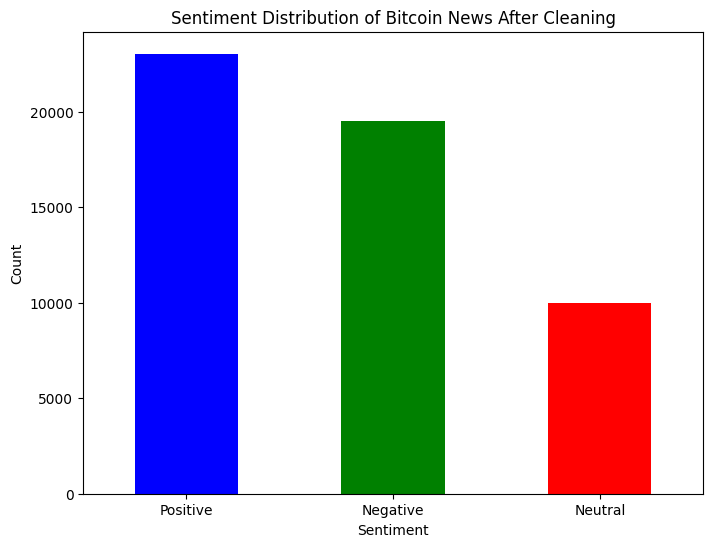

ع 10000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('processed_bitcoin_data_with_finBERT.csv')

df['final_date'] = pd.to_datetime(df['final_date'], errors='coerce')

df = df[df['final_date'] >= '2017-01-01']

sentiment_counts_before = df['f_sentiment'].value_counts()

df['f_sentiment'] = df['f_sentiment'].str.capitalize()

if sentiment_counts_before['Neutral'] > 10000:
    df_neutral = df[df['f_sentiment'] == 'Neutral']
    df_non_neutral = df[df['f_sentiment'] != 'Neutral']

    df_neutral = df_neutral.sample(n=10000, random_state=42)

    df = pd.concat([df_non_neutral, df_neutral])

sentiment_counts_after = df['f_sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts_after.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Sentiment Distribution of Bitcoin News After Cleaning')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

df.to_csv('processed_bitcoin_data_cleaned.csv', index=False)

print(f"ع {sentiment_counts_after['Neutral']}")


In [ ]:
import pandas as pd

df = pd.read_csv('processed_bitcoin_data_cleaned.csv')

df = df[['final_date', 'cleaned_text', 'f_sentiment', 'is_bitcoin_related', 'year']]

df.columns = ['date', 'text', 'sentiment', 'is_bitcoin_related', 'year']

df_other = pd.read_csv('bitcoin_messages_combined.csv')
print(df_other.columns)

df_other = df_other[['final_date', 'cleaned_text', 'sentiment', 'is_bitcoin_related', 'year']]

df_other.columns = ['date', 'text', 'sentiment', 'is_bitcoin_related', 'year']

df_combined = pd.concat([df, df_other], ignore_index=True)

df_combined.to_csv('co_bitcoin_data.csv', index=False)

print(df_combined.head())


Index(['date', 'text', 'cleaned_text', 'sentiment', 'is_bitcoin_related',
       'platform', 'final_date', 'year'],
      dtype='object')
         date                                               text sentiment  \
0  2017-03-03  fa insights is a daily newsletter from busines...  Positive   
1  2023-11-25  flickrdov harrington jcpenney is the biggest l...  Negative   
2  2023-03-03  fbi seizes black market site silk road arrests...  Negative   
3  2020-03-20  you can never have too many emoji and while ev...  Negative   
4  2020-05-26  by yoshifumi takemoto and sophie knight tokyo ...  Negative   

  is_bitcoin_related    year  
0               True  2017.0  
1               True  2023.0  
2               True  2023.0  
3               True  2020.0  
4               True  2020.0  


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("co_bitcoin_data.csv")

df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.date

if 'sentiment' not in df.columns:
    raise ValueError("تأكد من أن العمود 'sentiment' موجود في بياناتك")

df['year'] = df['date'].apply(lambda x: x.year if pd.notnull(x) else np.nan)
df['month'] = df['date'].apply(lambda x: x.month if pd.notnull(x) else np.nan)
df['day'] = df['date'].apply(lambda x: x.day if pd.notnull(x) else np.nan)

sentiment_counts = df.groupby(['date', 'sentiment']).size().unstack(fill_value=0)

sentiment_counts['total'] = sentiment_counts.sum(axis=1)

sentiment_counts['Negative_%'] = (sentiment_counts.get('Negative', 0) / sentiment_counts['total']) * 100
sentiment_counts['Neutral_%'] = (sentiment_counts.get('Neutral', 0) / sentiment_counts['total']) * 100
sentiment_counts['Positive_%'] = (sentiment_counts.get('Positive', 0) / sentiment_counts['total']) * 100

sentiment_counts['Weighted_Sentiment_Score'] = (
    (sentiment_counts.get('Positive', 0) * 1) +
    (sentiment_counts.get('Neutral', 0) * 0) +
    (sentiment_counts.get('Negative', 0) * -1)
) / sentiment_counts['total']

sentiment_counts.to_csv("prepared_data_after_removal.csv", index=True)



In [ ]:
import pandas as pd

df = pd.read_csv("co_bitcoin_data.csv")

print(df.columns)


Index(['date', 'text', 'sentiment', 'is_bitcoin_related', 'year'], dtype='object')


In [ ]:
import pandas as pd

df_combined = pd.read_csv("prepared_data_after_removal.csv")

df_combined['date'] = pd.to_datetime(df_combined['date'], errors='coerce')

df_combined['year'] = df_combined['date'].dt.year

sentiment_by_year = df_combined.groupby('year')[['Negative', 'Neutral', 'Positive', 'total']].sum()

sentiment_by_year['Negative_%'] = (sentiment_by_year['Negative'] / sentiment_by_year['total']) * 100
sentiment_by_year['Neutral_%'] = (sentiment_by_year['Neutral'] / sentiment_by_year['total']) * 100
sentiment_by_year['Positive_%'] = (sentiment_by_year['Positive'] / sentiment_by_year['total']) * 100

def determine_final_sentiment(row):
    max_sentiment = row[['Negative_%', 'Neutral_%', 'Positive_%']].idxmax()
    return max_sentiment.replace('_%', '')

sentiment_by_year['Final_Sentiment'] = sentiment_by_year.apply(determine_final_sentiment, axis=1)

sentiment_by_year['Weighted_Sentiment_Score'] = (
    (sentiment_by_year['Positive'] * 1) +
    (sentiment_by_year['Neutral'] * 0) +
    (sentiment_by_year['Negative'] * -1)
) / sentiment_by_year['total']

sentiment_by_year.to_csv("sentiment_by_year.csv", index=True)



In [ ]:
import pandas as pd

df_combined = pd.read_csv("sentiment_by_day_month_year.csv")

print(df_combined.columns)


Index(['day_month_year', 'Negative', 'Neutral', 'Positive', 'total',
       'Negative_%', 'Neutral_%', 'Positive_%', 'Weighted_Sentiment_Score',
       'Final_Sentiment'],
      dtype='object')


In [ ]:
df = pd.read_csv("sentiment_by_year.csv")

print(df.columns)


Index(['year', 'Negative', 'Neutral', 'Positive', 'total', 'Negative_%',
       'Neutral_%', 'Positive_%', 'Final_Sentiment',
       'Weighted_Sentiment_Score'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("co_bitcoin_data.csv")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.dropna(subset=["date", "sentiment"])

df["sentiment"] = df["sentiment"].str.strip()

df["year"] = df["date"].dt.year.fillna(0).astype(int)
df["month"] = df["date"].dt.month.fillna(0).astype(int)
df["day"] = df["date"].dt.day.fillna(0).astype(int)

df = df[df["year"] > 0]


sentiment_counts = df.groupby(["year", "month", "day", "sentiment"]).size().unstack(fill_value=0)

for sentiment in ["Positive", "Negative", "Neutral"]:
    if sentiment not in sentiment_counts.columns:
        sentiment_counts[sentiment] = 0

sentiment_counts["total"] = sentiment_counts.sum(axis=1)

sentiment_counts["positive_ratio"] = sentiment_counts["Positive"] / sentiment_counts["total"]
sentiment_counts["negative_ratio"] = sentiment_counts["Negative"] / sentiment_counts["total"]
sentiment_counts["neutral_ratio"] = sentiment_counts["Neutral"] / sentiment_counts["total"]

sentiment_counts = sentiment_counts.drop(columns=["total"])

sentiment_counts = sentiment_counts.reset_index()

if "sentiment" in sentiment_counts.columns:
    sentiment_counts = sentiment_counts.drop(columns=["sentiment"])

sentiment_counts.to_csv("daily_sentiment_ratios_by_year_month_day_after_removal.csv", index=False)

print(sentiment_counts.head())


sentiment  year  month  day  Negative  Neutral  Positive  positive_ratio  \
0          2017      1    1        17        8        15        0.375000   
1          2017      1    2        12        7        15        0.441176   
2          2017      1    3        28       14        17        0.288136   
3          2017      1    4         4        2         8        0.571429   
4          2017      1    5        11        3         6        0.300000   

sentiment  negative_ratio  neutral_ratio  
0                0.425000       0.200000  
1                0.352941       0.205882  
2                0.474576       0.237288  
3                0.285714       0.142857  
4                0.550000       0.150000  


<ipython-input-35-fa94e6c454fe>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["sentiment"].str.strip()
<ipython-input-35-fa94e6c454fe>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["date"].dt.year.fillna(0).astype(int)
<ipython-input-35-fa94e6c454fe>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

In [ ]:
sentiment_df = pd.read_csv("daily_sentiment_ratios_by_year_month_day_after_removal.csv")

print(sentiment_df.columns)

print(sentiment_df.head())


Index(['year', 'month', 'day', 'Negative', 'Neutral', 'Positive',
       'positive_ratio', 'negative_ratio', 'neutral_ratio'],
      dtype='object')
   year  month  day  Negative  Neutral  Positive  positive_ratio  \
0  2017      1    1        17        8        15        0.375000   
1  2017      1    2        12        7        15        0.441176   
2  2017      1    3        28       14        17        0.288136   
3  2017      1    4         4        2         8        0.571429   
4  2017      1    5        11        3         6        0.300000   

   negative_ratio  neutral_ratio  
0        0.425000       0.200000  
1        0.352941       0.205882  
2        0.474576       0.237288  
3        0.285714       0.142857  
4        0.550000       0.150000  


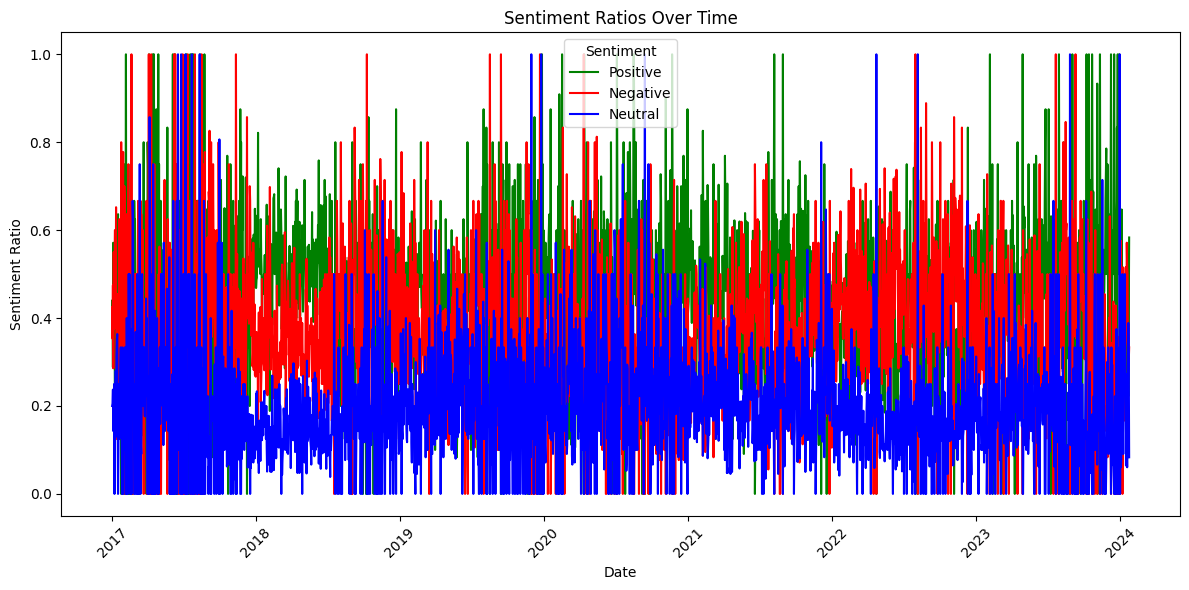

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("daily_sentiment_ratios_by_year_month_day_after_removal.csv")

df["date"] = pd.to_datetime(df[['year', 'month', 'day']])

plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x="date", y="positive_ratio", label="Positive", color="green")
sns.lineplot(data=df, x="date", y="negative_ratio", label="Negative", color="red")
sns.lineplot(data=df, x="date", y="neutral_ratio", label="Neutral", color="blue")

plt.title("Sentiment Ratios Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Ratio")
plt.legend(title="Sentiment")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files

files.download("daily_sentiment_ratios_by_year_month_day_after_removal.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

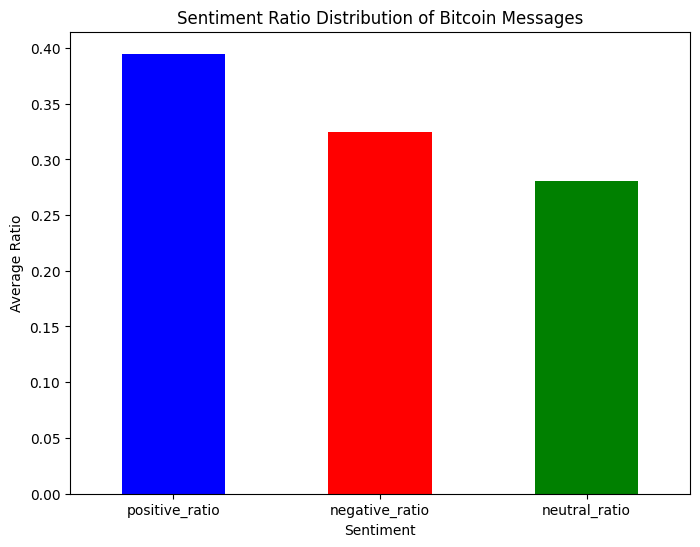

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('bitcoin_processed4.csv')

sentiment_counts = df[['positive_ratio', 'negative_ratio', 'neutral_ratio']].mean()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['blue', 'red', 'green'])
plt.title('Sentiment Ratio Distribution of Bitcoin Messages')
plt.xlabel('Sentiment')
plt.ylabel('Average Ratio')
plt.xticks(rotation=0)
plt.show()


In [ ]:
import pandas as pd

sentiment_df = pd.read_csv("daily_sentiment_ratios_by_year_month_day_after_removal.csv")

total_messages = sentiment_df[['Negative', 'Neutral', 'Positive']].sum().sum()

negative_messages = sentiment_df['Negative'].sum()
neutral_messages = sentiment_df['Neutral'].sum()
positive_messages = sentiment_df['Positive'].sum()

print(f"Total number of messages: {total_messages}")
print(f"Number of negative messages: {negative_messages}")
print(f"Number of neutral messages: {neutral_messages}")
print(f"Number of positive messages: {positive_messages}")



Total number of messages: 52551
Number of negative messages: 19505
Number of neutral messages: 10000
Number of positive messages: 23046


In [ ]:
print(merged_df[['date', 'year', 'month', 'day', 'close', 'high', 'low', 'open', 'volume', 'positive_ratio', 'negative_ratio', 'neutral_ratio']].head(10).to_string())

Empty DataFrame
Columns: [date, year, month, day, close, high, low, open, volume, positive_ratio, negative_ratio, neutral_ratio]
Index: []


In [ ]:
import pandas as pd

bitcoin_df = pd.read_csv('bitcoin_ohlc_cleaned.csv')

sentiment_df = pd.read_csv('merged_data_2017_2025.csv')

sentiment_df['date'] = pd.to_datetime(sentiment_df[['year', 'month', 'day']])

bitcoin_df['date'] = pd.to_datetime(bitcoin_df['date'])

merged_df = pd.merge(bitcoin_df, sentiment_df, on='date', how='inner')

print(merged_df.head())

merged_df.to_csv('merged_bi_sentiment_data.csv', index=False)



        date        close         high          low         open     volume  \
0 2017-01-31   970.403015   972.018982   920.958984   920.958984  164582000   
1 2017-02-01   989.023010   989.114014   970.742004   970.940979  150110000   
2 2017-02-02  1011.799988  1013.520020   983.221008   990.000977  145820992   
3 2017-02-03  1029.910034  1033.869995  1008.789978  1011.460022  201278000   
4 2017-02-04  1042.900024  1045.900024  1015.159973  1031.329956  155064000   

   year  month  day  Negative  Neutral  Positive  positive_ratio  \
0  2017      1   31         0        1         3        0.750000   
1  2017      2    1         7        1         2        0.200000   
2  2017      2    2         2        1         0        0.000000   
3  2017      2    3         4        6         8        0.444444   
4  2017      2    4         1        0         1        0.500000   

   negative_ratio  neutral_ratio  
0        0.000000       0.250000  
1        0.700000       0.100000  
2        0.

In [ ]:
import pandas as pd

merged_df = pd.read_csv("merged_bi_sentiment_data.csv")

if merged_df[['positive_ratio', 'negative_ratio', 'close']].isnull().any().any():
  merged_df = merged_df.dropna(subset=['positive_ratio', 'negative_ratio', 'close'])

merged_df['price_change'] = merged_df['close'].diff()

merged_df['momentum'] = merged_df['positive_ratio'] * merged_df['price_change'] - merged_df['negative_ratio'] * merged_df['price_change']

merged_df.to_csv('merged_bi_sentiment_data_with_momentum.csv', index=False)

print(merged_df[['date', 'close', 'positive_ratio', 'negative_ratio', 'price_change', 'momentum']].head())


         date        close  positive_ratio  negative_ratio  price_change  \
0  2017-01-01   998.325012        0.375000        0.425000           NaN   
1  2017-01-02  1021.750000        0.441176        0.352941     23.424988   
2  2017-01-03  1043.839966        0.288136        0.474576     22.089966   
3  2017-01-04  1154.729980        0.571429        0.285714    110.890015   
4  2017-01-05  1013.380005        0.300000        0.550000   -141.349976   

    momentum  
0        NaN  
1   2.066911  
2  -4.118468  
3  31.682861  
4  35.337494  


In [ ]:
print(merged_df[['date', 'close', 'positive_ratio', 'negative_ratio', 'price_change', 'momentum']].head(60))


          date        close  positive_ratio  negative_ratio  price_change  \
0   2017-01-01   998.325012        0.375000        0.425000           NaN   
1   2017-01-02  1021.750000        0.441176        0.352941     23.424988   
2   2017-01-03  1043.839966        0.288136        0.474576     22.089966   
3   2017-01-04  1154.729980        0.571429        0.285714    110.890015   
4   2017-01-05  1013.380005        0.300000        0.550000   -141.349976   
5   2017-01-06   902.200989        0.375000        0.375000   -111.179016   
6   2017-01-07   908.585022        0.500000        0.500000      6.384033   
7   2017-01-08   911.198975        0.200000        0.600000      2.613953   
8   2017-01-09   902.828003        0.200000        0.600000     -8.370972   
9   2017-01-10   907.679016        0.240000        0.480000      4.851013   
10  2017-01-11   777.757019        0.217391        0.652174   -129.921997   
11  2017-01-12   804.833984        0.562500        0.125000     27.076965   

In [ ]:
import pandas as pd

merged_df = pd.read_csv("merged_bi_sentiment_data.csv")

print(merged_df.columns)


Index(['date', 'close', 'high', 'low', 'open', 'volume', 'year', 'month',
       'day', 'Negative', 'Neutral', 'Positive', 'positive_ratio',
       'negative_ratio', 'neutral_ratio'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("bitcoin_processed5.csv")

df['date'] = pd.to_datetime(df['date'])

df['SMA_20'] = df['close'].rolling(window=20).mean()

df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['close'])

def calculate_bollinger_bands(data, window=20):
    sma = data.rolling(window=window).mean()
    rolling_std = data.rolling(window=window).std()
    upper_band = sma + (rolling_std * 2)
    lower_band = sma - (rolling_std * 2)
    return upper_band, lower_band

df['Bollinger_Upper'], df['Bollinger_Lower'] = calculate_bollinger_bands(df['close'])

df['Volatility'] = df['close'].rolling(window=20).std()

print(df.head())


        date        close         high          low         open     volume  \
0 2017-03-02  1251.010010  1262.130005  1215.619995  1224.680054  368275008   
1 2017-03-03  1274.989990  1280.310059  1250.709961  1250.709961  315739008   
2 2017-03-04  1255.150024  1279.400024  1230.510010  1277.430054  183270000   
3 2017-03-05  1267.119995  1267.290039  1238.060059  1254.290039  134127000   
4 2017-03-06  1272.829956  1276.000000  1264.599976  1267.469971  153656992   

   year  month  day  Negative  ...  neutral_ratio_Lag30  target_7_days  \
0  2017      3    2         3  ...             0.250000    1116.719971   
1  2017      3    3        57  ...             0.100000    1175.829956   
2  2017      3    4         2  ...             0.333333    1221.380005   
3  2017      3    5         1  ...             0.333333    1231.920044   
4  2017      3    6         0  ...             0.000000    1240.000000   

   target_14_days  target_30_days  SMA_20       EMA_20         RSI  \
0     1100

In [ ]:
import pandas as pd
import numpy as np

def calculate_additional_indicators(df):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['SMA_20'] = df['close'].rolling(window=20).mean()
    df['Std_Dev'] = df['close'].rolling(window=20).std()
    df['Bollinger_Upper'] = df['SMA_20'] + (df['Std_Dev'] * 2)
    df['Bollinger_Lower'] = df['SMA_20'] - (df['Std_Dev'] * 2)

    df['Volatility'] = df['close'].rolling(window=20).std() / df['close'].rolling(window=20).mean()

    if 'positive_ratio_Lag7' not in df.columns:
        pass

    df.fillna(0, inplace=True)
    return df

df = pd.read_csv("bitcoin_processed5.csv")

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df = calculate_additional_indicators(df)

print(df.columns.tolist())

output_filename = "bitcoin_processed_with_features.csv"
df.to_csv(output_filename, index=False)
print(f"\nتم حفظ الملف مع الميزات الجديدة باسم: {output_filename}")

In [ ]:
import pandas as pd

df = pd.read_csv("bitcoin_processed_with_features.csv")

for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

1. date
2. close
3. high
4. low
5. open
6. volume
7. year
8. month
9. day
10. Negative
11. Neutral
12. Positive
13. positive_ratio
14. negative_ratio
15. neutral_ratio
16. close_Lag7
17. close_Lag14
18. close_Lag30
19. high_Lag7
20. high_Lag14
21. high_Lag30
22. low_Lag7
23. low_Lag14
24. low_Lag30
25. open_Lag7
26. open_Lag14
27. open_Lag30
28. volume_Lag7
29. volume_Lag14
30. volume_Lag30
31. positive_ratio_Lag7
32. positive_ratio_Lag14
33. positive_ratio_Lag30
34. negative_ratio_Lag7
35. negative_ratio_Lag14
36. negative_ratio_Lag30
37. neutral_ratio_Lag7
38. neutral_ratio_Lag14
39. neutral_ratio_Lag30
40. target_7_days
41. target_14_days
42. target_30_days
43. RSI
44. SMA_20
45. Std_Dev
46. Bollinger_Upper
47. Bollinger_Lower
48. Volatility


In [ ]:
df.to_csv("updated_bi_sentiment_data.csv", index=False)
print(df.head(60))


         date        close         high          low         open     volume  \
0  2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008   
1  2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992   
2  2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000   
3  2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984   
4  2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008   
5  2017-01-06   902.200989  1046.810059   883.943970  1014.239990  351876000   
6  2017-01-07   908.585022   908.585022   823.556030   903.487000  279550016   
7  2017-01-08   911.198975   942.723999   887.249023   908.174988  158715008   
8  2017-01-09   902.828003   913.685974   879.807007   913.244019  141876992   
9  2017-01-10   907.679016   914.872986   901.059998   902.440002  115808000   
10 2017-01-11   777.757019   919.447998   762.765015   908.114990  310928992   
11 2017-01-12   804.833984   826.245972 

In [ ]:
print(df.head(60))


         date        close         high          low         open     volume  \
0  2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008   
1  2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992   
2  2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000   
3  2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984   
4  2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008   
5  2017-01-06   902.200989  1046.810059   883.943970  1014.239990  351876000   
6  2017-01-07   908.585022   908.585022   823.556030   903.487000  279550016   
7  2017-01-08   911.198975   942.723999   887.249023   908.174988  158715008   
8  2017-01-09   902.828003   913.685974   879.807007   913.244019  141876992   
9  2017-01-10   907.679016   914.872986   901.059998   902.440002  115808000   
10 2017-01-11   777.757019   919.447998   762.765015   908.114990  310928992   
11 2017-01-12   804.833984   826.245972 

In [ ]:
import pandas as pd

df = pd.read_csv("updated_bi_sentiment_data.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

def create_lag_features(df, column, max_lag):
    for lag in range(1, max_lag + 1):
        df[f'{column}_Lag{lag}'] = df[column].shift(lag)
    return df

df = create_lag_features(df, 'close', 30)

df = create_lag_features(df, 'positive_ratio', 30)
df = create_lag_features(df, 'negative_ratio', 30)
df = create_lag_features(df, 'neutral_ratio', 30)

df['target_7_days'] = df['close'].shift(-7)
df['target_14_days'] = df['close'].shift(-14)
df['target_30_days'] = df['close'].shift(-30)

df = df.dropna()

df.to_csv("bitcoin_data_lagged.csv", index=False)

print(df.head())



<ipython-input-1-ea2ef827de07>:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{column}_Lag{lag}'] = df[column].shift(lag)
<ipython-input-1-ea2ef827de07>:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{column}_Lag{lag}'] = df[column].shift(lag)
<ipython-input-1-ea2ef827de07>:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

         date        close         high          low         open     volume  \
30 2017-01-31   970.403015   972.018982   920.958984   920.958984  164582000   
31 2017-02-01   989.023010   989.114014   970.742004   970.940979  150110000   
32 2017-02-02  1011.799988  1013.520020   983.221008   990.000977  145820992   
33 2017-02-03  1029.910034  1033.869995  1008.789978  1011.460022  201278000   
34 2017-02-04  1042.900024  1045.900024  1015.159973  1031.329956  155064000   

    year  month  day  Negative  ...  neutral_ratio_Lag24  neutral_ratio_Lag25  \
30  2017      1   31         0  ...             0.000000                 0.25   
31  2017      2    1         7  ...             0.200000                 0.00   
32  2017      2    2         2  ...             0.200000                 0.20   
33  2017      2    3         4  ...             0.280000                 0.20   
34  2017      2    4         1  ...             0.130435                 0.28   

    neutral_ratio_Lag26  neutral

In [ ]:
import pandas as pd

df = pd.read_csv("merged_bi_sentiment_data.csv")
print(df.tail(10))


            date         close          high           low          open  \
2927  2025-03-18  82718.500000  84075.718750  81179.992188  84075.718750   
2928  2025-03-19  86854.226562  87021.187500  82569.726562  82718.804688   
2929  2025-03-20  84167.195312  87443.265625  83647.195312  86872.953125   
2930  2025-03-21  84043.242188  84782.273438  83171.070312  84164.539062   
2931  2025-03-22  83832.484375  84513.875000  83674.781250  84046.257812   
2932  2025-03-23  86054.375000  86094.781250  83794.914062  83831.898438   
2933  2025-03-24  87498.914062  88758.726562  85541.195312  86070.929688   
2934  2025-03-25  87471.703125  88542.398438  86346.078125  87512.820312   
2935  2025-03-26  86900.882812  88292.156250  85861.453125  87460.234375   
2936  2025-03-27  87177.101562  87786.726562  85837.937500  86896.257812   

           volume  year  month  day  Negative  Neutral  Positive  \
2927  24095774594  2025      3   18        25      119        23   
2928  34931960257  2025    

In [ ]:
import pandas as pd

df = pd.read_csv("merged_bi_sentiment_data.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

def create_lag_features(df, column, max_lag):
    lagged_columns = []
    for lag in range(1, max_lag + 1):
        lagged_columns.append(df[column].shift(lag).rename(f'{column}_Lag{lag}'))
    return pd.concat([df] + lagged_columns, axis=1)

df = create_lag_features(df, 'close', 30)

df = create_lag_features(df, 'positive_ratio', 30)
df = create_lag_features(df, 'negative_ratio', 30)
df = create_lag_features(df, 'neutral_ratio', 30)

df['target_7_days'] = df['close'].shift(-7)
df['target_14_days'] = df['close'].shift(-14)
df['target_30_days'] = df['close'].shift(-30)

df = df.dropna()

df.to_csv("bitcoin_d_lagged.csv", index=False)

print(df.head())



         date        close         high          low         open     volume  \
30 2017-03-02  1251.010010  1262.130005  1215.619995  1224.680054  368275008   
31 2017-03-03  1274.989990  1280.310059  1250.709961  1250.709961  315739008   
32 2017-03-04  1255.150024  1279.400024  1230.510010  1277.430054  183270000   
33 2017-03-05  1267.119995  1267.290039  1238.060059  1254.290039  134127000   
34 2017-03-06  1272.829956  1276.000000  1264.599976  1267.469971  153656992   

    year  month  day  Negative  ...  neutral_ratio_Lag24  neutral_ratio_Lag25  \
30  2017      3    2         3  ...             0.000000             0.000000   
31  2017      3    3        57  ...             0.400000             0.000000   
32  2017      3    4         2  ...             0.222222             0.400000   
33  2017      3    5         1  ...             0.000000             0.222222   
34  2017      3    6         0  ...             0.000000             0.000000   

    neutral_ratio_Lag26  neutral

In [ ]:
print(df.columns)

df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df['date'] = pd.to_datetime(df['date'])


Index(['year', 'month', 'day', 'Negative', 'Neutral', 'Positive',
       'positive_ratio', 'negative_ratio', 'neutral_ratio'],
      dtype='object')


In [ ]:
import pandas as pd

df = pd.read_csv("bitcoin_processed_final.csv")

df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

features = ['close', 'high', 'low', 'open', 'volume', 'positive_ratio', 'negative_ratio']

for feature in features:
    for lag in lags:
        df[f'{feature}_Lag{lag}'] = df[feature].shift(lag)

df['target_7_days'] = df['close'].shift(-7)
df['target_14_days'] = df['close'].shift(-14)
df['target_30_days'] = df['close'].shift(-30)

df.dropna(inplace=True)

df.to_csv("bitcoin_processed5.csv", index=False)

print(df.head())


         date        close         high          low         open     volume  \
30 2017-04-02  1102.170044  1107.589966  1075.449951  1080.609985  514187008   
31 2017-04-03  1143.810059  1151.739990  1102.949951  1102.949951  580444032   
32 2017-04-04  1133.250000  1156.439941  1120.520020  1145.520020  436310016   
33 2017-04-05  1124.780029  1135.089966  1113.630005  1134.140015  414784000   
34 2017-04-06  1182.680054  1188.369995  1125.810059  1125.810059  511222016   

    year  month  day  Negative  ...  volume_Lag30  positive_ratio_Lag7  \
30  2017      4    2         0  ...   368275008.0             0.437500   
31  2017      4    3         3  ...   315739008.0             0.428571   
32  2017      4    4         1  ...   183270000.0             0.400000   
33  2017      4    5         0  ...   134127000.0             0.000000   
34  2017      4    6         1  ...   153656992.0             1.000000   

    positive_ratio_Lag14  target_7_days  target_14_days  target_30_days  \

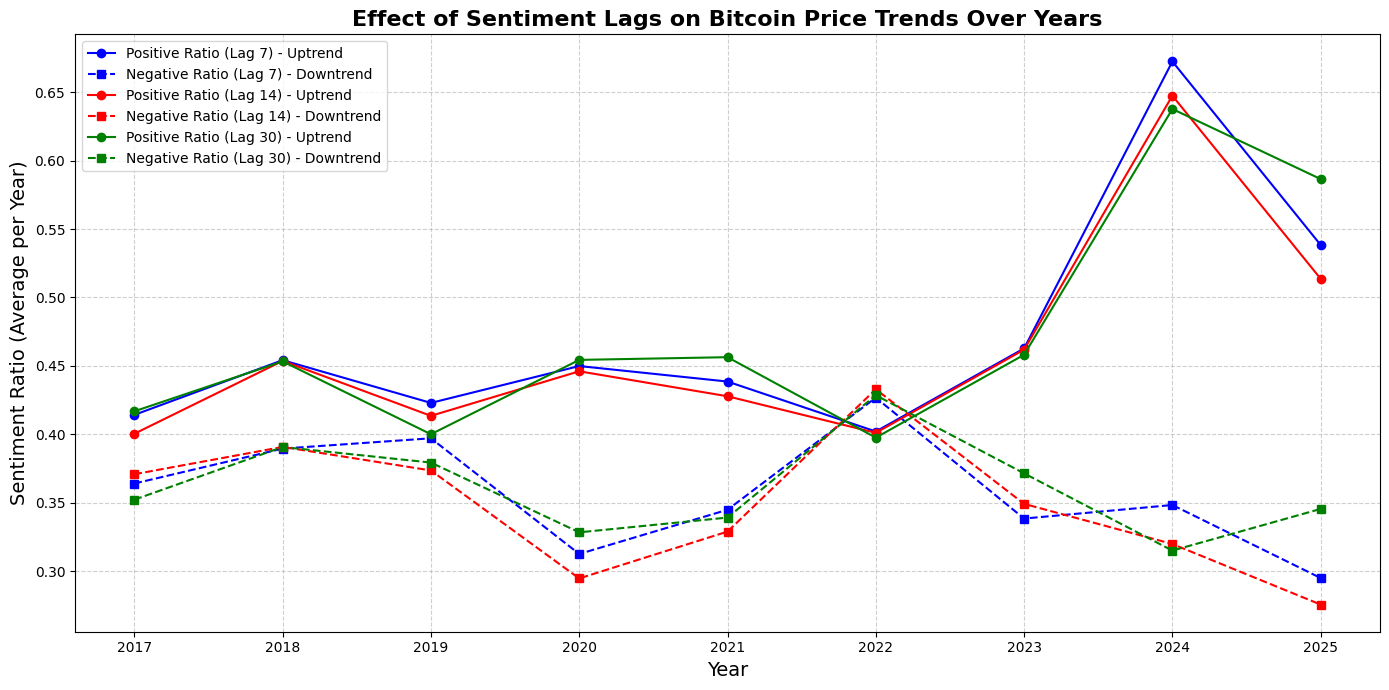

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bitcoin_processed5.csv")

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df['price_trend'] = df['close'].diff().apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

lags = [7, 14, 30]
colors = ['blue', 'red', 'green']

plt.figure(figsize=(14, 7))

for i, lag in enumerate(lags):
    avg_positive = df[df['price_trend'] == 1].groupby('year')[f'positive_ratio_Lag{lag}'].mean()
    plt.plot(avg_positive.index, avg_positive, label=f'Positive Ratio (Lag {lag}) - Uptrend', linestyle='-', marker='o', color=colors[i])

    avg_negative = df[df['price_trend'] == -1].groupby('year')[f'negative_ratio_Lag{lag}'].mean()
    plt.plot(avg_negative.index, avg_negative, label=f'Negative Ratio (Lag {lag}) - Downtrend', linestyle='--', marker='s', color=colors[i])

plt.title('Effect of Sentiment Lags on Bitcoin Price Trends Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Sentiment Ratio (Average per Year)', fontsize=14)
plt.xticks(df['year'].unique())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


<ipython-input-3-09c4937a2368>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_trend', y=f'positive_ratio_Lag30_trend', palette="coolwarm")


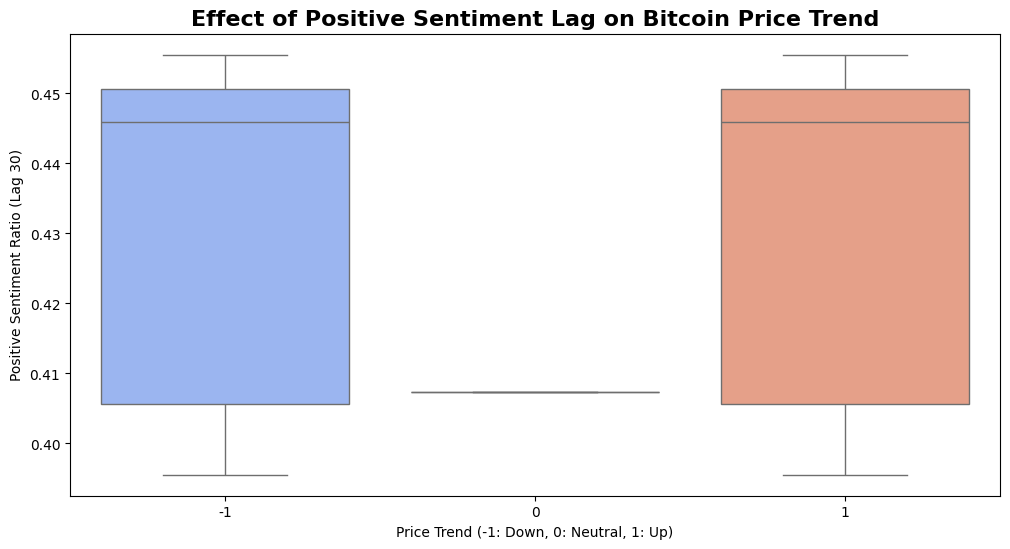

In [ ]:
plt.figure(figsize=(12, 6))

for i, lag in enumerate(lags):
    df[f'positive_ratio_Lag{lag}_trend'] = df.groupby('year')[f'positive_ratio_Lag{lag}'].transform('mean')
    df[f'negative_ratio_Lag{lag}_trend'] = df.groupby('year')[f'negative_ratio_Lag{lag}'].transform('mean')

sns.boxplot(data=df, x='price_trend', y=f'positive_ratio_Lag30_trend', palette="coolwarm")
plt.title("Effect of Positive Sentiment Lag on Bitcoin Price Trend", fontsize=16, fontweight='bold')
plt.xlabel("Price Trend (-1: Down, 0: Neutral, 1: Up)")
plt.ylabel("Positive Sentiment Ratio (Lag 30)")
plt.show()
